# Calculating Oxygen Fugacity from Spinel-Olivine-Melt equilibria

We have incorporated a new method for using MELTS calculations of spinel-olivine-melt equilibria to calculate the oxygen fugacity into PetThermoTools. 

**Please make sure to cite the original study. This work was developed by Bell et al. 2025 and the data used in this example was taken from their supplementary materials (https://doi.org/10.2138/am-2023-9021).**

As a method in PetThermoTools the MELTS_OSaS barometer is still in development, so if you notice any bugs etc. please let me know. For now you must provide the same number of olivine, spinel, and melt compositions. If you load in only one melt composition (intending to apply it to all olivine-spinel pairs) the function will not work. Make sure the number of rows in the melt/liquid dataframe is the same as the number of rows in the olivine and spinel dataframes.

The MELTS OSaS barometer utilizes the MELTS thermodynamic engine to calculate the oxygen fugacity of the system using the reaction:

$$ 3Fe_2SiO_{4}^{oliv} + O_{2}^{sys} = 2Fe_3O_{4}^{sp} + 3SiO_{2}^{melt} $$

meaning that the chemical potential of $O_2$ can be defined as:

$$ \mu_{O_{2}}^{sys} = 2\mu_{SiO_{2}}^{melt} + 2\mu_{Fe_{3}O_{4}}^{sp} - 2\mu_{Fe_{2}SiO_{4}}^{oliv} $$

and the oxygen fugacity calcualted using the standard state thermodynamic data for $O_2$ from the JANAF tables (Chase, 1998) and:

$$ \mu_{O_{2}}^{sys} - \mu_{O_{2}}^{o} = RTln(fO_2) $$

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import petthermotools as ptt 
ptt.__version__ # this will only work with v0.3.2 or later.

alphaMELTS for Python files successfully located.
If using the Green et al. (2025) or Weller et al. (2024) thermodynamic models please run `ptt.activate_petthermotools_env()` prior to any calculations.


'0.4.6'

In [3]:
# Should be used to suppress outputs on MacOS - run twice - if on windows, wont do anything. 
import platform
if platform.system() == "Darwin":
    import sys
    import os
    sys.stdout = open(os.devnull, 'w')
    sys.stderr = open(os.devnull, 'w')

First we can load in the melt, olivine, and spinel data from the Bell et al. supplement. We'll also load in the original dataset from Bell et al. which includes the known $fO_2$ of each experiment as well as the pressure (in MPa) and the temperature (in Celsuis). As with all PetThermoTools calculations we require the temperture in Celsius and the pressure in bars.

In [4]:
data = pd.read_excel("Melt_OSaS_example.xlsx", sheet_name = "Original Data")
liq = pd.read_excel("Melt_OSaS_example.xlsx", sheet_name = "Melt")
ol = pd.read_excel("Melt_OSaS_example.xlsx", sheet_name = "Olivine")
spl = pd.read_excel("Melt_OSaS_example.xlsx", sheet_name = "Spinel")

There is then a single function that works to calculate oxygen fugacity, using the correction from Bell et al. 2025 to adjust the chemical potential of the magnetite end member in the spinel solid solution:

In [5]:
logfO2 = ptt.MELTS_OSaS(liq=liq, ol=ol, spl=spl, T_C = data['Temperature'], P_bar = data['Pressure']*10)

we can then check the performance of the MELTS OSaS oxybarometer by plotting the calculated $fO_2$ against the known $fO_2$ from the experimental data.

Text(0, 0.5, 'Calculated $fO_2$')

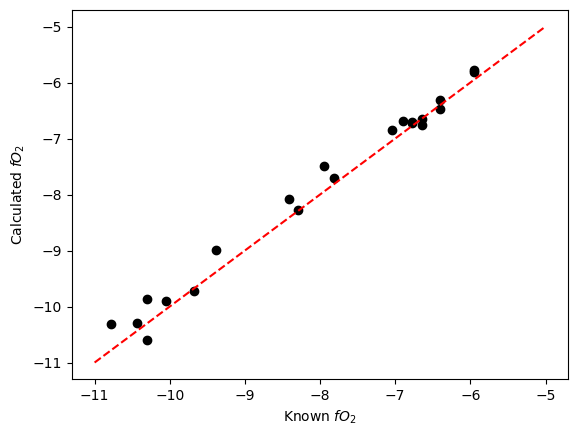

In [6]:
plt.figure()
plt.plot(data['logfO2 known'], logfO2, 'ok')
plt.plot([-11,-5],[-11,-5], '--r')
plt.xlabel('Known $fO_2$')
plt.ylabel('Calculated $fO_2$')